## Loading data

In [44]:
import pandas as pd 
import matplotlib.pyplot as plt

heart = pd.read_csv("heart.csv")
heart.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


**Attribute information (copied from the source)**

1. Age: age of the patient [years]
2. Sex: sex of the patient [M: Male, F: Female]
3. ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
4. RestingBP: resting blood pressure [mm Hg]
5. Cholesterol: serum cholesterol [mm/dl]
6. FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
7. RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), 
8. LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
9. MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
10.  ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
11. Oldpeak: oldpeak = ST [Numeric value measured in depression]
12. ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
13. HeartDisease: output class [1: heart disease, 0: Normal]

## Overview of the dataset  

In [45]:
heart.info()
heart.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

The dataset consists of 918 rows (observations) and 12 columns (features). It has 6 integer features, 5 string features and 1 float feature. 
It has neither missing values, nor NULL values. 

- Age is a numerical continuous variable. 
- Sex is a categorical nominal variable. (binary)
- ChestPainType is a categorical nominal variable. 
- RestingBP is a numerical continuous variable.
- MaxHR is a numerical continuous variable. 
- ExerciseAngina is a categorical nominal variable. (binary)
- Oldpeak is a numerical continuous variable. 
- ST_Slope is a categorical ordinal variable. 
- HeartDisease is a categorical nominal variable. (binary)
- FastingBS is a categorical nominal variable. (binary)
- Cholesterol is a numerical continuous variable. 
- RestingECG is a a categorical nominal variable. 

In [46]:
heart.duplicated().sum()

np.int64(0)

In [47]:
heart["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

The dataset contains 508 patients with heart disease and 410 patients without heart disease.

## Data visualization

### Age analysis

Minimum age:  28
Maximum age:  77


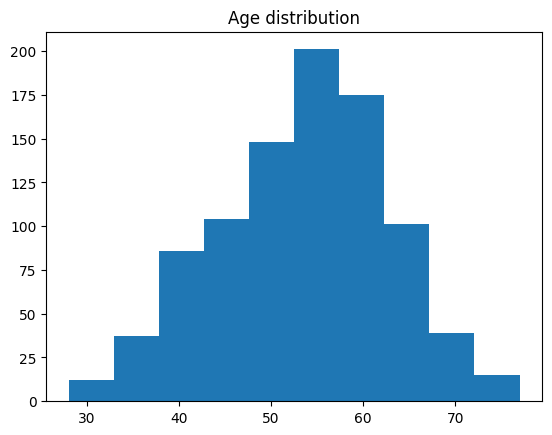

In [48]:
plt.hist(heart["Age"])
plt.title("Age distribution")

print("Minimum age: ", heart["Age"].min())  
print("Maximum age: ", heart["Age"].max())



The dataset includes people from different age groups, where the minimum age is 28, and the maximum age is 77. The majority of patients in the dataset are between ~50 and ~60 years old, while younger age groups include fewer observations. This may be because heart diease is more common in older age groups, so older patients are more represented in the dataset. 

Overall, the dataset seems to be more representative of middle-aged and odler patients. So predictions may be more reliable for these age groups and less reliable for younger patients, since there are fewer younger observations.

<Axes: title={'center': 'Age'}, xlabel='HeartDisease'>

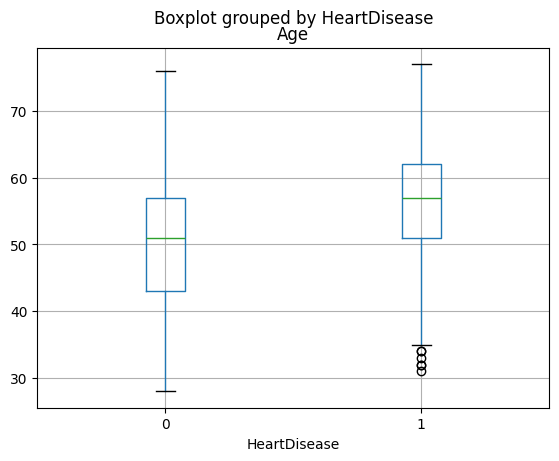

In [49]:
heart.boxplot(column = "Age", by = "HeartDisease")

The first boxplot describes the age group that does not have a heart disease, while the second one represents people with a heart disease. 

The median of the second boxplot is placed much higher than the median of the first boxplot, which means that people with heart disease tend to be older. 
The inter quartile range of the second boxplot is smaller, so the middle 50% of age values of people with heart disease has lower variability. It means that heart diseases are more concentrated within a specific age range.

Lower whisker of the second boxplot reaches ~35, which indicates that heart disease is less common among younger people in this dataset. However, there are some outliers in the range ~30 - 35 years old, which shows that people from this age group can still get heart problems, even though it is not that common in this case. 

So the age can be an important feature for predicting heart disease in this dataset.

### Gender analysis

Women with heart disease:  50
Women without heart disease:  143
Men with heart disease:  458
Men without heart disease:  267


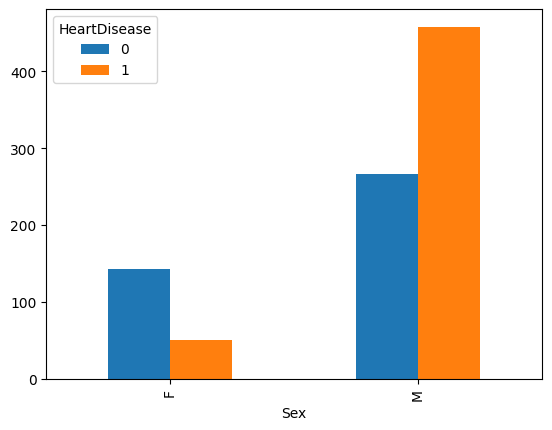

In [50]:
pd.crosstab(heart["Sex"], heart["HeartDisease"]).plot(kind = "bar")

female_disease = heart[heart["Sex"] == "F"]["HeartDisease"].value_counts()
male_disease = heart[heart["Sex"] == "M"]["HeartDisease"].value_counts()

print("Women with heart disease: ", female_disease[1])
print("Women without heart disease: ", female_disease[0])

print("Men with heart disease: ", male_disease[1])
print("Men without heart disease: ", male_disease[0])




The barplot shows that the dataset is imbalanced in terms of gender, as most of the observations describe male patients. That is why future predictions may be less reliable for women due to fewer female examples.

But based on existing data, men have a higher proportion of heart disease in this dataset. Out of 725 men, 458 of them have a heart disease, which is ~63.17%.
The situation is different for women. Out of 193 women, only 50 have a heart disease, which is ~25.91%. 

So as a result, most of patients with heart disease (at least in this dataset) are men. However, it is important to keep in mind that the dataset does not contain many female patients. It is still possible for women to have heart disease, but prediction results could be much better if the dataset had more female patients.


### Max heart rate analysis

Minimum Max heart rate:  60


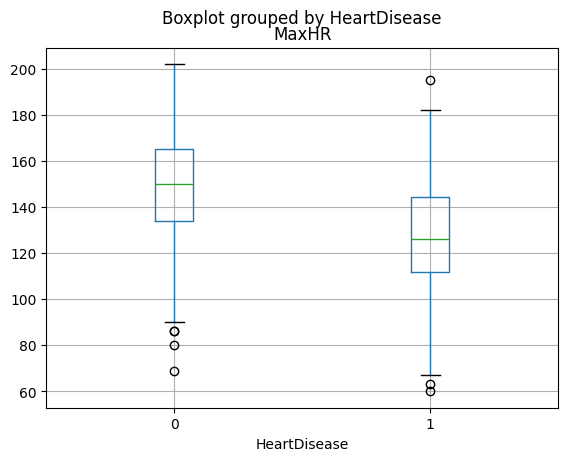

In [51]:
heart.boxplot(column = "MaxHR", by = "HeartDisease")
print("Minimum Max heart rate: ", heart["MaxHR"].min())

In general, boxplots of MaxHR show that people with heart disease tend to have lower maximum heart rate in this dataset. 
The median of the second boxplot is located under the box of the first boxplot, showing that it mostly contains of lower values. 

The overall spread of the values is similar for both groups. But the boxplot for patients without heart disease one is shifted higher, so its middle range of MaxHR values is bigger.

Both of them have some outliers. The first boxplot shows that patients can have low maximum heart rate even without heart disease. And the second boxplot shows some patients with heart disease can still have high or extremely low maximum heart rate. But as these observations are considered outliers, these cases are not that common in this dataset. 

### Oldpeak analysis

<Axes: title={'center': 'Oldpeak'}, xlabel='HeartDisease'>

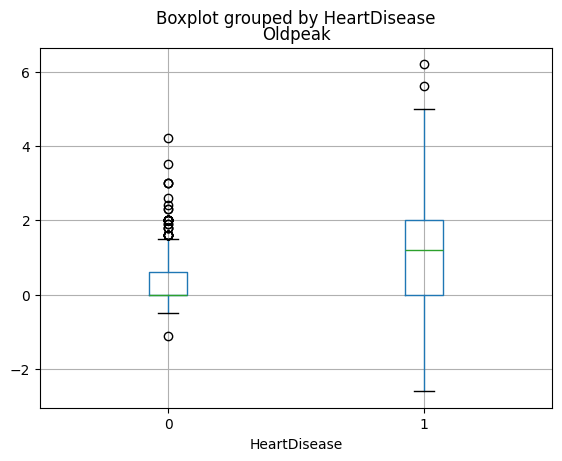

In [52]:
heart.boxplot(column = "Oldpeak", by = "HeartDisease")

**Explanation of what ST depression and ST segments are**

*"...if the ST segment appears abnormally low and sits below the baseline, then a person is said to have ST depression. Clinically speaking, the ST segment represents the period in the cardiac cycle when the muscular layer of the heart contracts to expel blood from the ventricles."* 

(C) MedicalNewsToday "What does ST depression on an ECG result mean?"

*"Factors affecting the ST-T and U wave configuration include:*

*Intrinsic myocardial disease (e.g., myocarditis, ischemia, infarction, infiltrative or myopathic processes)*

*Drugs (e.g., digoxin, quinidine, tricyclics, and many others)*

*Electrolyte abnormalities of potassium, magnesium, calcium*

*Neurogenic factors (e.g., stroke, hemorrhage, trauma, tumor, etc.)*

*Metabolic factors (e.g., hypoglycemia, hyperventilation)*

*Atrial repolarization (e.g., at fast heart rates the atrial T wave may pull down the beginning of the ST segment)*

*Ventricular conduction abnormalities and rhythms originating in the ventricles "*

(C) ST segment abnormalities. University of Utah ECG Learning Center



The first boxplot represents people without heart disease. Its median is on the same level as its first quartile (0), which shows that there can be repeated values among low values. It makes sense, because Oldpeak = 0 means no measured ST depression relative to rest, so it should be a very common result among patients without heart disease. But it was mentioned that ST-T configuration could also be affected by individual physiological characteristics or medications, which explains some deviations from 0 in the middle range and the existence of larger and smaller outliers. 

The second boxplot looks very different from the first one. Its median is higher, and the box is shifted upward, meaning that patients with heart disease in this dataset generally have higher ST-depression values. Both of its whiskers are very long, showing that values exist in a wide range from ~(-2.5) to ~5 (with some outliers that are larger than 5). Negative Oldpeak values probably indicate ST-elevation, because it would explain their existence in the second boxplot. The middle 50% of the second boxplot ranges from 0 to 2, so some ST-depression results can still overlap between "heart disease" and "no heart disease" cases. 

Summing up, ST-depression can be a good feature to predict heart disease, as its range of values is much larger for patients with heart disease. But it still requires checking other parameters, because ST-T configuration can be affected by other factors.

### Chest pain type analysis

<Axes: xlabel='ChestPainType'>

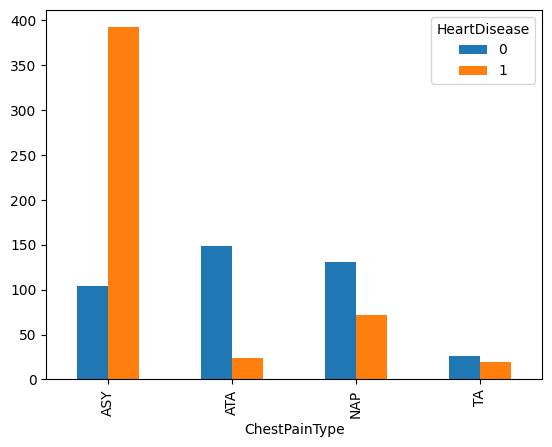

In [53]:
pd.crosstab(heart["ChestPainType"], heart["HeartDisease"]).plot(kind = "bar")

**Chest pain types**

*- Typical angina (definite) - "Substernal chest discomfort with a characteristic quality and duration that is (2) provoked by exertion or emotional stress and (3) relieved by rest or nitroglycerin"*

*- Atypical angina (probable) - Meets 2 of the above characteristics*

*- Noncardiac chest pain - Meets ≤1 of the typical angina characteristics*

(C) ACC/AHA/ACP–ASIM Guidelines for the Management of Patients With Chronic Stable Angina: Executive Summary and Recommendations

Most of the patients with heart disease in the dataset belong to the asymptomatic category of the chest pain type. It means that they did not report any chest pain, even though angina is one of the most common heart disease symptoms. One possible explanation is that many heart disease cases in the dataset were detected through other indicators and or symptoms. It could be very useful for the analysis, because it may be more difficult to make a diagnosis without a common symptom.

Patients without heart disease tend to have more cases of symptomatic chest pain type. A possible reason for that is that pain type does not define a final diagnosis, and it could be caused by other factors.

As a result, even though chest pain is usually a good symptom to consider heart disease, in this case the existence of chest pain does not mean the patient has a higher chance of having heart disease. So chest pain type must be considered with other features to predict heart disease.

### Exercise angina analysis

<Axes: xlabel='ExerciseAngina'>

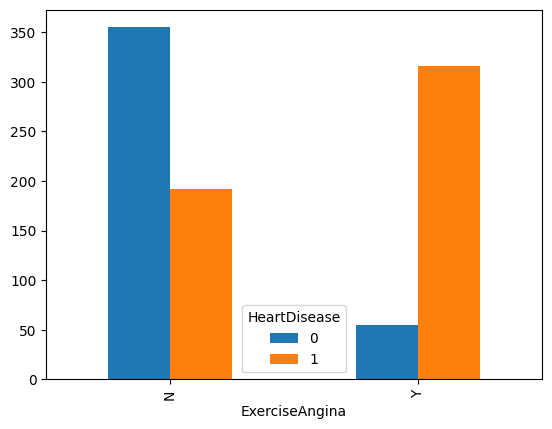

In [54]:
pd.crosstab(heart["ExerciseAngina"], heart["HeartDisease"]).plot(kind = "bar")

The bar chart shows that most of the people with heart disease reported having angina symptoms during the exercise. It means that even though many patients with heart disease did not report any chest pain, angina may have appeared during exercise or a stress test. Some of the patients with heart disease did not have angina symptoms during exercise. Perhaps, this may be possible due to the specific characteristics of a particular condition or the individual's unique physiology. 

And people without heart disease tend not to get any angina symptoms during exercise in this dataset, which was expected. Some of the observations still include angina, but it could be caused by other factors. 

As a result, exercise angina can be a useful feature for predicting heart disease.


### ST slope analysis

<Axes: xlabel='ST_Slope'>

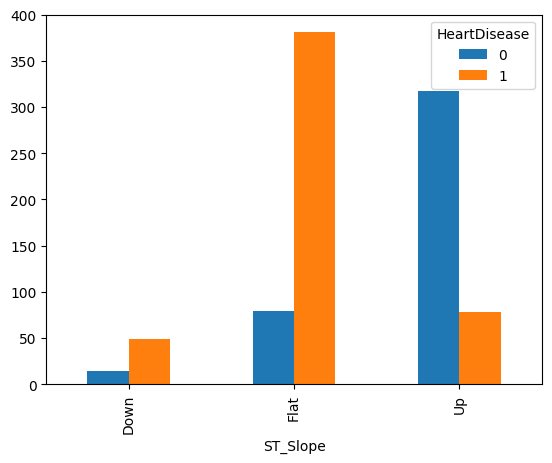

In [55]:
pd.crosstab(heart["ST_Slope"], heart["HeartDisease"]).plot(kind = "bar")

*"Horizontal or downsloping ST depression ≥ 0.5 mm at the J-point in ≥ 2 contiguous leads indicates myocardial ischaemia "*

*"Upsloping ST depression is non-specific for myocardial ischaemia."*
(C)LITFL Myocardial Ischaemia ECG Library

The bar plot demonstrates that most patients with heart disease in the dataset have flat shaped ST slope, which can be a more concerning pattern, so it makes sense. The upsloping ST depression is not specific for heart disease, which explains why most of patients without heart disease appear in the "Up" group. 

The "down" category contains the smallest number of observations, but the majority of this group still consists of people with heart disease.

The ST_Slope can already be very helpful in heart disease prediction as an individual feature, even though other factors should also be considered for a more reliable result. 



### Cholesterol analysis

Quantity of missing values: 172


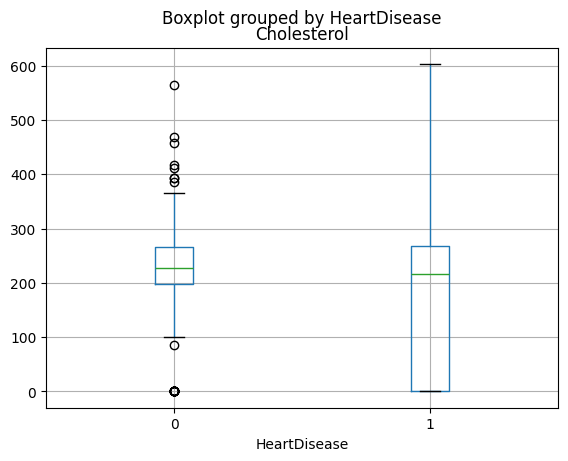

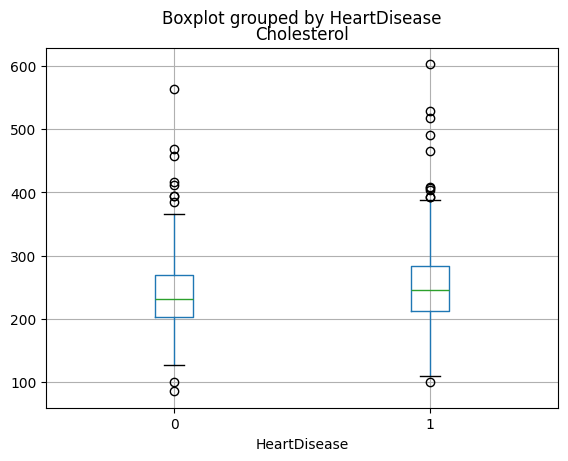

In [56]:
heart.boxplot(column = "Cholesterol", by = "HeartDisease")
heart[heart["Cholesterol"] != 0].boxplot(column = "Cholesterol", by = "HeartDisease")

print("Quantity of missing values:", (heart["Cholesterol"] == 0).sum())

*"Cholesterol is a waxy substance your body uses to build cells and to make hormones. Your body needs some cholesterol, but having too much in your blood increases the risk of heart disease and stroke."*
(C) American Heart Association. "What is cholesterol?"

Original dataset has observations with cholesterol = 0, which should probably be treated as either missing data or mistakes in collecting data.
These observations were temporarily removed just to get a general idea on how cholesterol level differs between "heart disease" and "no heart disease" cases. 

During preprocessing, missing values will be replaced with the median to avoid losing information.

After removing observations with missing values, it is much easier to interpret the results. Cholesterol values of both groups overlap a lot, but patient with heart disease have slightly larger values, which is expected, because high cholesterol can contribute to heart disease. 

However, high cholesterol does not always lead to heart disease, and not every person with heart disease has high cholesterol. That is why the results of the two groups overlap, and cholesterol level should always be considered together with other features to make a reliable conclusion. 

### FastingBS analysis

<Axes: xlabel='FastingBS'>

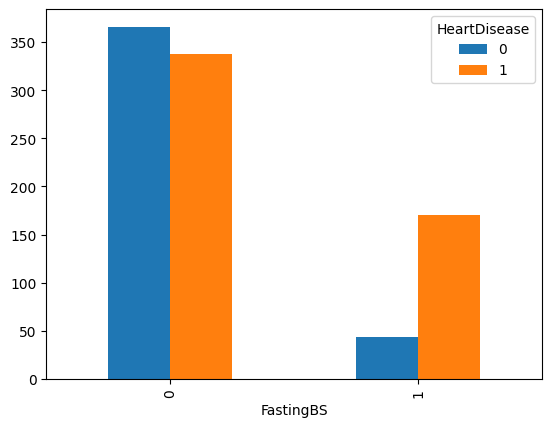

In [57]:
pd.crosstab(heart["FastingBS"], heart["HeartDisease"]).plot(kind = "bar")

*FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]*

The second bar plot shows that most patients with high fasting blood sugar level have heart disease. Such sugar level can be related to prediabetes or diabetes risk, which may contribute to heart disease risk in the future. It may be one of the explanations why the majority of people with high fasting sugar level in this dataset have heart disease. Some patients without heart disease also have a high fasting blood sugar level, but not every person with potential prediabetes/diabetes already has heart disease.

The first barplot has almost the same number of people with and without heart disease. It also makes sense, because normally fasting sugar level is supposed to be low, and not every heart disease is caused by sugar related problems. 

At the end, fasting blood sugar can be a useful predictive feature, when the patient has elevated fasting blood sugar. But as both groups overlap when FastingBS = 0, predictions may require taking other factors into consideration.

### RestingECG analysis

<Axes: xlabel='RestingECG'>

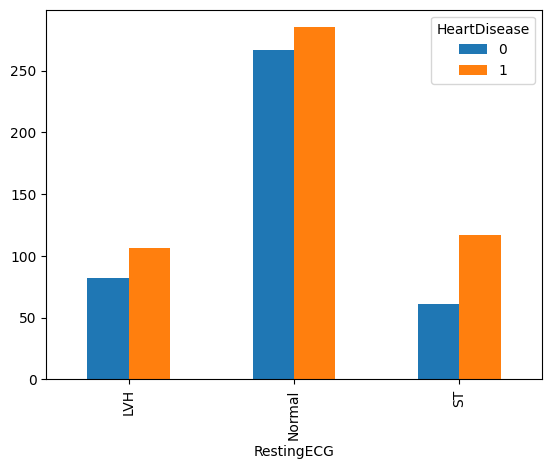

In [58]:
pd.crosstab(heart["RestingECG"], heart["HeartDisease"]).plot(kind = "bar")

The bar plot shows that most of patients, including ones with and without heart disease, have a normal resting ECG. LVH and ST groups contain almost the same number of patients. But people with heart disease still have slightly higher counts than people without heart disease.

It all means that in most cases resting ECG does not show any abnormalities in this dataset, but this feature can still be helpful in predictions when considered with other factors.

### RestingBP analysis

Minimum RestingBP:  0
Quantity of missing values:  1


<Axes: title={'center': 'RestingBP'}, xlabel='HeartDisease'>

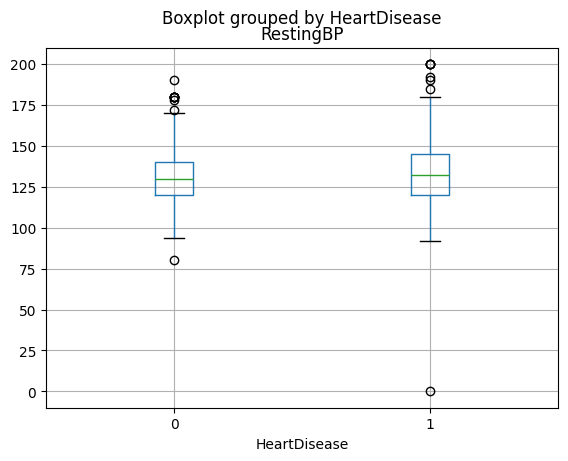

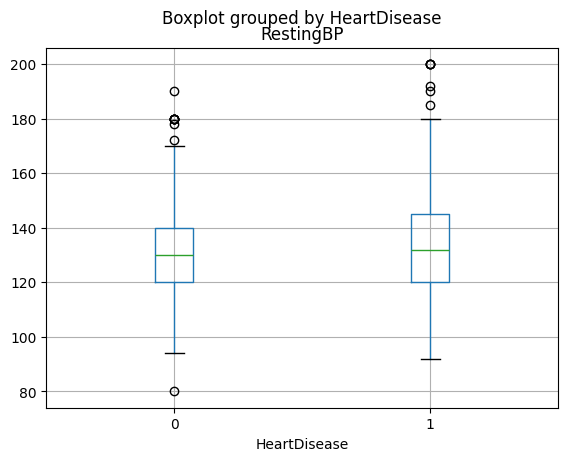

In [59]:
heart.boxplot(column = "RestingBP", by = "HeartDisease")
print("Minimum RestingBP: ", heart["RestingBP"].min())
print("Quantity of missing values: ", (heart["RestingBP"] == 0).sum())

heart[heart["RestingBP"] != 0].boxplot(column = "RestingBP", by = "HeartDisease")

One of the observations has RestingBP = 0, which is not possible. This observation was excluded from the visualization for avoiding data distortion, and it will be removed during data preprocessing.

The boxplot shows that both groups have very similar values. Patients with heart disease may have slightly higher resting blood pressure, but the results mostly overlap between people with and without heart disease.

RestingBP may not be one of the strong individual features, but it is still important to take it into consideration with other factors before making predictions. 



## CONCLUSION

Twelve features were analyzed with respect to the heart disease outcome. 
As a result, four of them could potentially have a strong influence, as they showed a clear difference between the two groups during visual analysis and did not overlap as much: 

1) ST_Slope: 
- Most of the cases with the flat ST slope appeared to be heart-disease positive, and there was a clear difference between people with and without heart disease for other ST slope groups.

2) ExerciseAngina:
- ExerciseAngina may have a strong influence on the prediction, because the majority of patients with heart disease experienced angina during exercise, while most patients without heart disease did not have any symptoms of angina during the stress test.

3) ChestPainType: 
- ChestPainType shows a strong pattern, because most of the patients in the asymptomatic category had heart disease, but it does not mean the existence of chest pain is not important. It means that patients without any chest pain should be analyzed even more carefully to find other potential medical indicators, as most patients in this dataset appeared to reveal their diagnosis through other factors. 

4) Oldpeak:
- Even though some patients without heart disease had some large-value outliers, most of their results were still concentrated around zero (no ST depression). In the case of patients with heart disease, their Oldpeak values ranged from negative (ST-elevation) to very large positive values (ST-depression), and their group contained more large values than the group without heart disease.

The rest of the features are still important for future predictions and must be considered. But on the visual analysis level they did not give that much information as the four previously mentioned features because of overlapping and imbalanced data (as in the case of gender). 

